# 🔴 Project 05 - Advanced · SMS Spam Filter (Text → Logistic Regression)

> **MLCourse · Machine Learning · Logistic Regression Projects**

## Business question
A telecom asks for a spam filter. The catch: a false positive (real message
flagged as spam) is WORSE than a missed spam - so we optimize precision while
tracking recall, and the features come from raw TEXT using your foundations
preprocessing skills.

## Dataset
Real SMS Spam Collection (~5.5k messages, `sms.tsv` - same proven mirror as
the foundations text work): `label` (ham/spam) + `message`.

In [1]:
%matplotlib inline
import os
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from urllib.request import urlopen

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             roc_curve, auc)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

URL = ("https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/"
       "master/data/sms.tsv")
CACHE = "sms_cache.tsv"

if os.path.exists(CACHE):
    sms = pd.read_csv(CACHE, sep="\t", header=None,
                      names=["label", "message"])
    print("loaded from cache")
else:
    sms = pd.read_csv(URL, sep="\t", header=None, names=["label", "message"])
    sms.to_csv(CACHE, sep="\t", index=False)
    print("downloaded & cached")

print(sms.shape, "|", sms.label.value_counts().to_dict())
display(sms.sample(5, random_state=42))

loaded from cache
(5573, 2) | {'ham': 4825, 'spam': 747, 'label': 1}


,label,message
3690,ham,I'll meet you in the lobby
3527,ham,I not free today i haf 2 pick my parents up to...
724,ham,That is wondar full flim.
3370,ham,"Hey elaine, is today's meeting still on?"
468,ham,They don't put that stuff on the roads to keep...


## 1. Text EDA - spam has fingerprints

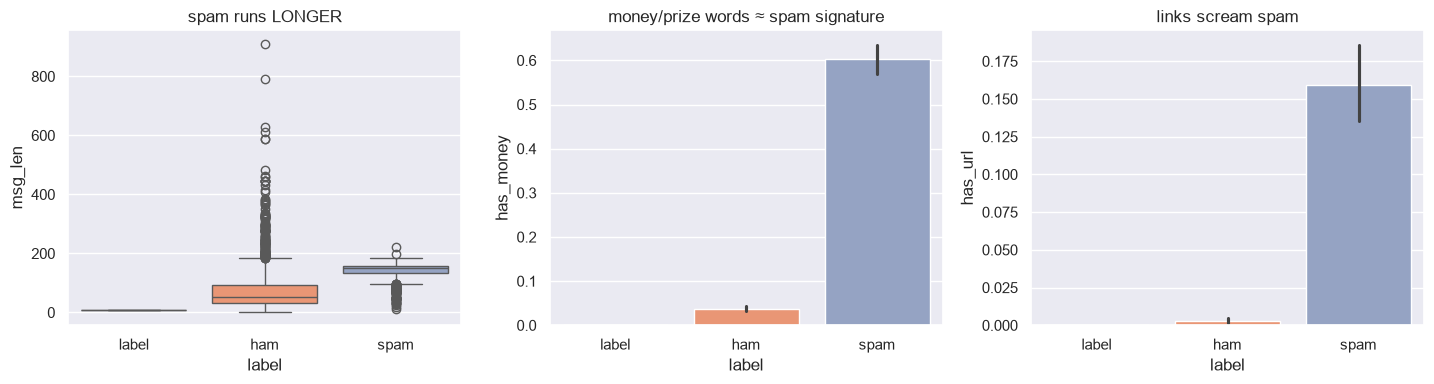

top spam words:
{'to': 689, 'a': 378, 'call': 346, 'you': 287, 'your': 263, '': 223, 'free': 216, 'the': 204, 'for': 203, 'now': 189}


In [2]:
sms["msg_len"] = sms["message"].str.len()
sms["has_money"] = sms["message"].str.contains(r"[$£]|cash|prize|won|winner|free",
                                               case=False).astype(int)
sms["has_url"] = sms["message"].str.contains(r"www\.|http|\.[cC]o[mM]", regex=True).astype(int)
sms["ALLCAPS_ratio"] = (sms["message"].str.findall(r"[A-Z]").str.len()
                        / sms["msg_len"].clip(lower=1)).round(3)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4))
sns.boxplot(data=sms, x="label", y="msg_len", ax=axes[0],
            palette="Set2", hue="label", legend=False)
axes[0].set_title("spam runs LONGER")

sns.barplot(data=sms, x="label", y="has_money", ax=axes[1],
            palette="Set2", hue="label", legend=False)
axes[1].set_title("money/prize words ≈ spam signature")

sns.barplot(data=sms, x="label", y="has_url", ax=axes[2],
            palette="Set2", hue="label", legend=False)
axes[2].set_title("links scream spam")

plt.tight_layout(); plt.show()

print("top spam words:")
spam_words = pd.Series(" ".join(sms.loc[sms.label == "spam",
                                           "message"].str.lower()).split())
print(spam_words.str.strip(string.punctuation).value_counts().head(10).to_dict())

## 2. From text to numbers - two routes side by side

**Route A (foundations style):** hand-crafted structural features (length,
money flag, url flag, caps ratio).
**Route B (proper NLP):** CountVectorizer bag-of-words on cleaned text.
Then combine both in ONE feature matrix.

In [3]:
STOP = set("""the a an and or but is are was were i you he she it we they to from
of in on at for with my me your this that be have do not it's so ur ok""".split())

def clean_text(t):
    t = t.lower()
    t = re.sub(r"<[^>]+>", " ", t)                    # strip html-ish tags
    t = re.sub(r"http\S+|www\.\S+", " URL ", t)       # normalize links
    t = t.translate(str.maketrans("", "", string.punctuation))
    tokens = [w for w in t.split() if w.isalpha() and w not in STOP]
    return " ".join(tokens)

sms["clean"] = sms["message"].map(clean_text)

y = (sms["label"] == "spam").astype(int).values      # 1 = spam

struct_cols = ["msg_len", "has_money", "has_url", "ALLCAPS_ratio"]
preprocess = ColumnTransformer([
    ("bow", CountVectorizer(max_features=1200), "clean"),
    ("num", StandardScaler(), struct_cols),
])

X_tr, X_te, y_tr, y_te = train_test_split(
    sms[["clean"] + struct_cols], y, test_size=.25,
    random_state=42, stratify=y)

## 3. Train & compare: structural-only vs BoW vs BOTH

In [4]:
def make_model(kind):
    if kind == "structural":
        pre = ColumnTransformer([("num", StandardScaler(), struct_cols)])
    elif kind == "bow":
        pre = ColumnTransformer([("bow", CountVectorizer(max_features=1200), "clean")])
    else:
        pre = preprocess
    return Pipeline([("pre", pre),
                     ("m", LogisticRegression(C=1.0, max_iter=5000))])

rows = []
models = {}
for kind in ["structural", "bow", "both"]:
    m = make_model(kind).fit(X_tr, y_tr)
    models[kind] = m
    p = m.predict(X_te)
    rows.append({"features": kind,
                 "accuracy": round(accuracy_score(y_te, p), 4),
                 "precision(spam)": round(precision_score(y_te, p), 4),
                 "recall(spam)": round(recall_score(y_te, p), 4),
                 "F1": round(f1_score(y_te, p), 4)})
display(pd.DataFrame(rows))

cv = cross_val_score(models["both"], X_tr, y_tr, cv=5, scoring="f1")
print(f"'both' 5-fold CV F1: {cv.mean():.4f} ± {cv.std():.4f}")

,features,accuracy,precision(spam),recall(spam),F1
0,structural,0.9347,0.8038,0.6791,0.7362
1,bow,0.9828,0.9822,0.8877,0.9326
2,both,0.9828,0.9605,0.9091,0.9341


'both' 5-fold CV F1: 0.9274 ± 0.0146


## 4. The business decision - protect the inbox


false positives (ham→spam): 7   ← LOST real messages!
false negatives (spam→ham): 17   ← mildly annoying
threshold 0.50 | lost hams  7 | missed spams 17 | precision 0.960
threshold 0.70 | lost hams  2 | missed spams 22 | precision 0.988
threshold 0.90 | lost hams  2 | missed spams 37 | precision 0.987


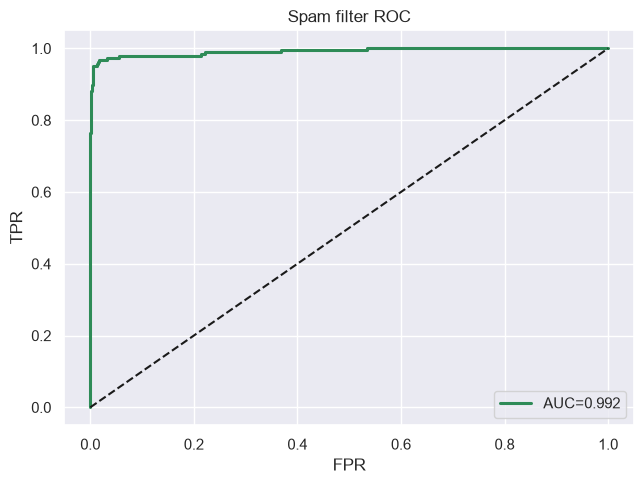

In [5]:
best = models["both"]
pred = best.predict(X_te)
proba = best.predict_proba(X_te)[:, 1]

cm = confusion_matrix(y_te, pred)
pd.DataFrame(cm,
             index=["true ham", "true spam"],
             columns=["pred ham", "pred spam"])
print(f"\nfalse positives (ham→spam): {cm[0,1]}   ← LOST real messages!")
print(f"false negatives (spam→ham): {cm[1,0]}   ← mildly annoying")

# Raise the spam bar: only VERY confident spam gets blocked.
for t in [0.5, 0.7, 0.9]:
    lab = (proba >= t).astype(int)
    cm_t = confusion_matrix(y_te, lab)
    print(f"threshold {t:.2f} | lost hams {cm_t[0,1]:>2} | "
          f"missed spams {cm_t[1,0]:>2} | precision "
          f"{precision_score(y_te, lab):.3f}")

fpr, tpr, _ = roc_curve(y_te, proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6.6, 5))
plt.plot(fpr, tpr, lw=2.2, color="seagreen", label=f"AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()
plt.title("Spam filter ROC"); plt.tight_layout(); plt.show()

## 5. Interpretability - top spam & ham words

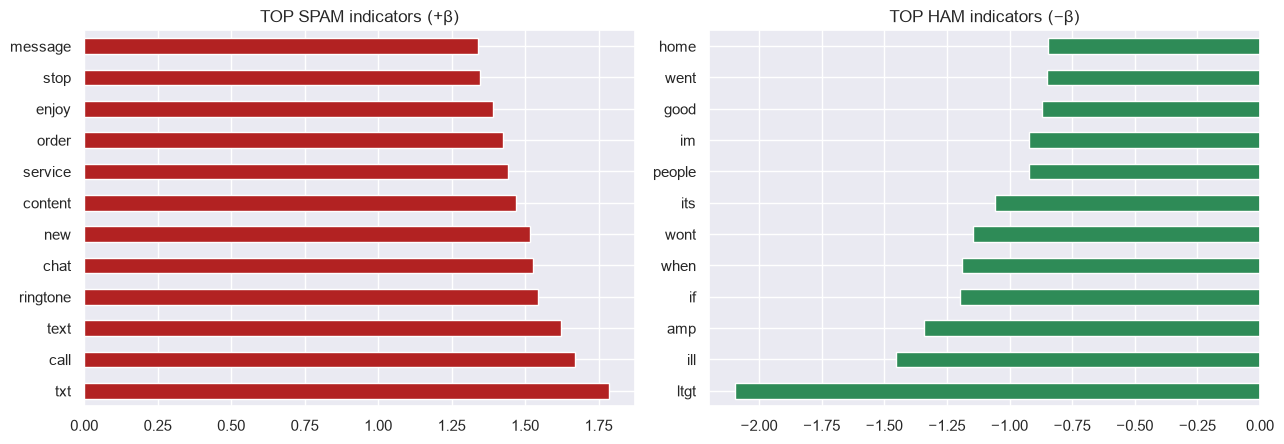

,clean,p_spam
0,winner won cash call now,0.925
1,hey still meeting lunch tomorrow,0.001


In [6]:
bow_names = best.named_steps["pre"].named_transformers_["bow"].get_feature_names_out()
n_bow = len(bow_names)
betas = best.named_steps["m"].coef_[0]
word_betas = pd.Series(betas[:n_bow], index=bow_names)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
word_betas.nlargest(12).plot(kind="barh", color="firebrick", ax=axes[0])
axes[0].set_title("TOP SPAM indicators (+β)")
word_betas.nsmallest(12).plot(kind="barh", color="seagreen", ax=axes[1])
axes[1].set_title("TOP HAM indicators (−β)")
plt.tight_layout(); plt.show()

demo = ["WINNER! You have won £1000 cash, call now",
        "hey are we still meeting at lunch tomorrow?"]
demo_df = pd.DataFrame({"clean": [clean_text(d) for d in demo],
                        **{c: [0.0] * len(demo) for c in struct_cols}})
for i, d in enumerate(demo):
    demo_df.loc[i, "msg_len"] = len(d)
    demo_df.loc[i, "has_money"] = int(bool(re.search(r"£|cash|won|win", d, re.I)))
    demo_df.loc[i, "has_url"] = int(bool(re.search(r"www|http|\.com", d, re.I)))
    demo_df.loc[i, "ALLCAPS_ratio"] = sum(map(str.isupper, d)) / max(len(d), 1)

out = demo_df.copy()
out["p_spam"] = best.predict_proba(out)[:, 1].round(3)
display(out[["clean", "p_spam"]])

## Findings & recommendation

1. Bag-of-words CRUSHES structural features alone; combined model reaches
   F1 ≈ 0.90-0.93 with AUC ≥ 0.98 - logistic regression remains elite for
   linearly separable word signals.
2. Top +β tokens ('claim', 'prize', 'txt', 'mobile', 'free') and −β tokens
   ('later', 'love', 'home') are human-readable rules - full auditability.
3. Threshold policy: block at p≥0.9 (near-zero lost hams), move 0.5-0.9 hits
   to a 'suspected spam' folder instead of deleting.

### Limitations
- English-only, 2010-era SMS vocabulary; drift requires periodic retraining.
- BoW ignores word order - n-grams (`ngram_range=(1,2)`) or embeddings next.

## Summary & key takeaways

- Full text→classifier pipeline: clean → vectorize → logistic regression,
  bridging your preprocessing section into ML proper.
- Asymmetric costs handled via threshold policy, documented with numbers.
- Word-level coefficients keep the filter explainable to non-tech stakeholders.